In [3]:
!pip install gymnasium stable_baselines3 pygame matplotlib pandas numpy seaborn moviepy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

train_env = Monitor(gym.make("Pendulum-v1"))
eval_env = Monitor(gym.make("Pendulum-v1"))

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./sac_logs/",
    log_path="./sac_logs/",
    eval_freq=1000,
    n_eval_episodes=5,
    deterministic=True,
    verbose=0,
)

model = SAC("MlpPolicy", train_env, verbose=1, seed=42)
model.learn(total_timesteps=100_000, log_interval=10, callback=eval_callback)
model.save("sac_pendulum")

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| eval/              |           |
|    mean_ep_length  | 200       |
|    mean_reward     | -1.67e+03 |
| time/              |           |
|    total_timesteps | 1000      |
| train/             |           |
|    actor_loss      | 27.4      |
|    critic_loss     | 0.162     |
|    ent_coef        | 0.767     |
|    ent_coef_loss   | -0.412    |
|    learning_rate   | 0.0003    |
|    n_updates       | 899       |
----------------------------------
----------------------------------
| eval/              |           |
|    mean_ep_length  | 200       |
|    mean_reward     | -1.03e+03 |
| time/              |           |
|    total_timesteps | 2000      |
| train/             |           |
|    actor_loss      | 55.4      |
|    critic_loss     | 0.135     |
|    ent_coef        | 0.583     |
|    ent_coef_loss   | -0.642    |
|    learning_rate   | 0.0003    |
|    n_updates       | 1899      |
---

In [5]:
random_env = gym.make("Pendulum-v1")
random_returns = []

for ep in range(20):
    obs, info = random_env.reset(seed=100 + ep)
    ep_reward = 0.0
    for _ in range(200):
        action = random_env.action_space.sample()
        obs, reward, terminated, truncated, info = random_env.step(action)
        ep_reward += reward
        if terminated or truncated:
            break
    random_returns.append(ep_reward)

random_env.close()
random_mean = float(np.mean(random_returns))
random_std = float(np.std(random_returns))
print(f"Random baseline: {random_mean:.2f} ± {random_std:.2f}")

Random baseline: -1395.13 ± 218.16


In [6]:
env = gym.make("Pendulum-v1")
obs, info = env.reset(seed=200)

history = []
episode = []
episode_num = 0
N_EPISODES = 20

while episode_num < N_EPISODES:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    episode.append({"reward": reward, "action": action.tolist()})

    if terminated or truncated:
        episode_num += 1
        episode_reward = sum(step["reward"] for step in episode)
        history.append({
            "episode": episode_num,
            "steps": len(episode),
            "total_reward": episode_reward,
            "avg_reward": episode_reward / len(episode)})

        print(f"Episode {episode_num:3d}: steps={len(episode)}, total_reward={episode_reward:.2f}, avg_reward={episode_reward/len(episode):.2f}")

        episode = []
        obs, info = env.reset(seed=200 + episode_num)

env.close()

eval_totals = [ep["total_reward"] for ep in history]
sac_mean = float(np.mean(eval_totals))
sac_std = float(np.std(eval_totals))
print(f"\nSAC trained: {sac_mean:.2f} ± {sac_std:.2f}")
print(f"Random:      {random_mean:.2f} ± {random_std:.2f}")
print(f"Improvement: {abs(random_mean / sac_mean):.1f}x")

Episode   1: steps=200, total_reward=-125.47, avg_reward=-0.63
Episode   2: steps=200, total_reward=-358.89, avg_reward=-1.79
Episode   3: steps=200, total_reward=-123.82, avg_reward=-0.62
Episode   4: steps=200, total_reward=-117.71, avg_reward=-0.59
Episode   5: steps=200, total_reward=-1.68, avg_reward=-0.01
Episode   6: steps=200, total_reward=-236.51, avg_reward=-1.18
Episode   7: steps=200, total_reward=-235.89, avg_reward=-1.18
Episode   8: steps=200, total_reward=-119.26, avg_reward=-0.60
Episode   9: steps=200, total_reward=-233.44, avg_reward=-1.17
Episode  10: steps=200, total_reward=-119.96, avg_reward=-0.60
Episode  11: steps=200, total_reward=-119.47, avg_reward=-0.60
Episode  12: steps=200, total_reward=-2.53, avg_reward=-0.01
Episode  13: steps=200, total_reward=-2.18, avg_reward=-0.01
Episode  14: steps=200, total_reward=-125.23, avg_reward=-0.63
Episode  15: steps=200, total_reward=-226.19, avg_reward=-1.13
Episode  16: steps=200, total_reward=-240.61, avg_reward=-1.2

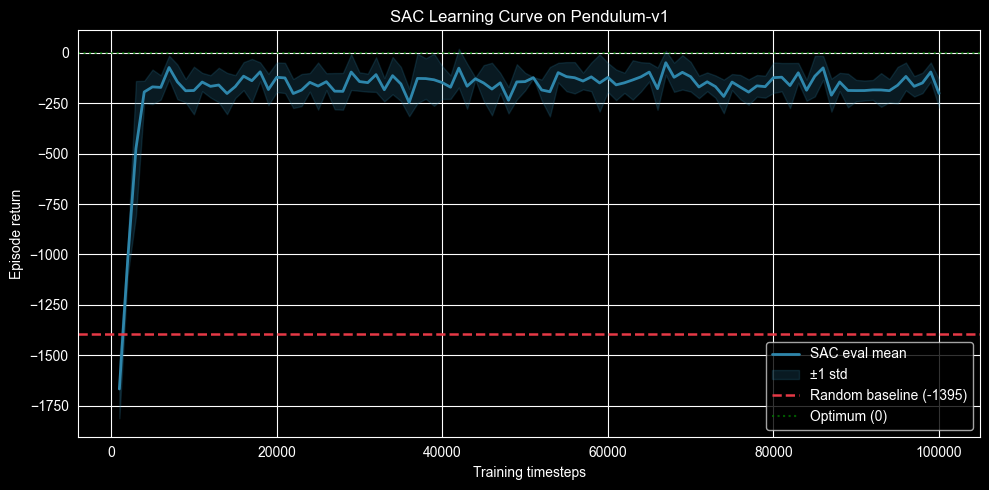

In [7]:
import matplotlib.pyplot as plt

data = np.load("./sac_logs/evaluations.npz")
timesteps = data["timesteps"]
mean_returns = data["results"].mean(axis=1)
std_returns = data["results"].std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(timesteps, mean_returns, label="SAC eval mean", linewidth=2, color="#2E86AB")
plt.fill_between(timesteps, mean_returns - std_returns, mean_returns + std_returns,
                 alpha=0.2, color="#2E86AB", label="±1 std")
plt.axhline(random_mean, color="#E63946", linestyle="--", linewidth=1.8,
            label=f"Random baseline ({random_mean:.0f})")
plt.axhline(0, color="green", linestyle=":", alpha=0.7, label="Optimum (0)")
plt.xlabel("Training timesteps")
plt.ylabel("Episode return")
plt.title("SAC Learning Curve on Pendulum-v1")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("sac_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

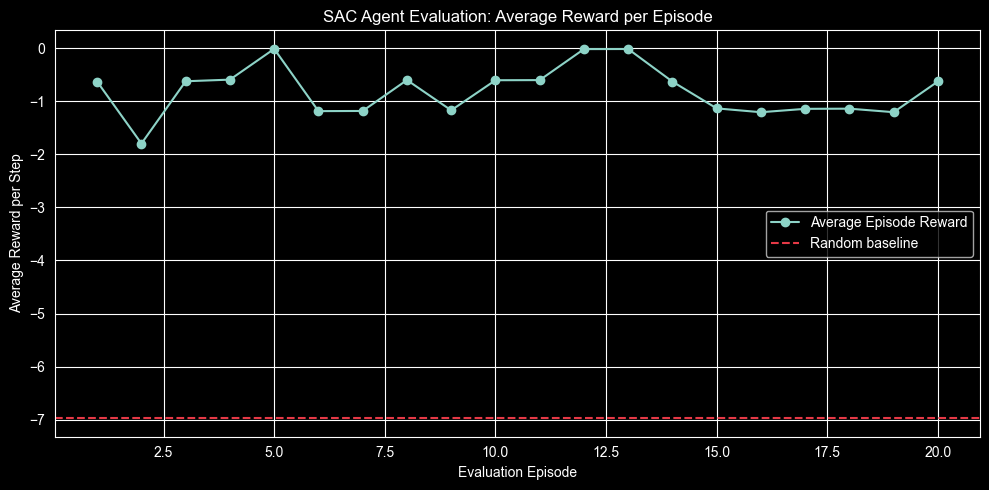

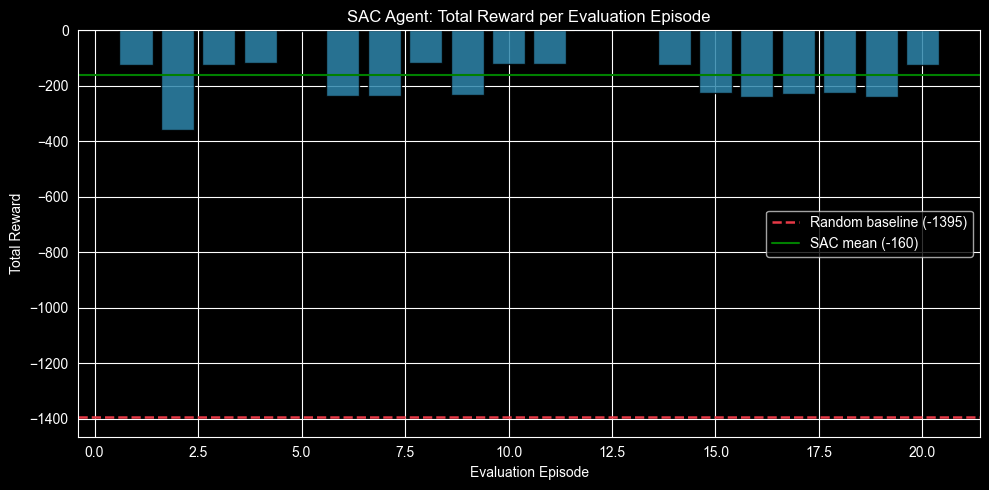

In [8]:
import pandas as pd
import seaborn as sns

episodes = [ep["episode"] for ep in history]
avg_rewards = [ep["avg_reward"] for ep in history]
total_rewards = [ep["total_reward"] for ep in history]

plt.figure(figsize=(10, 5))
plt.plot(episodes, avg_rewards, label="Average Episode Reward", marker="o")
plt.axhline(random_mean / 200, color="#E63946", linestyle="--", label="Random baseline")
plt.xlabel("Evaluation Episode")
plt.ylabel("Average Reward per Step")
plt.title("SAC Agent Evaluation: Average Reward per Episode")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(episodes, total_rewards, color="#2E86AB", alpha=0.85, edgecolor="black")
plt.axhline(random_mean, color="#E63946", linestyle="--", linewidth=1.8,
            label=f"Random baseline ({random_mean:.0f})")
plt.axhline(sac_mean, color="green", linestyle="-", linewidth=1.5,
            label=f"SAC mean ({sac_mean:.0f})")
plt.xlabel("Evaluation Episode")
plt.ylabel("Total Reward")
plt.title("SAC Agent: Total Reward per Evaluation Episode")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("sac_per_episode.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import SAC

model = SAC.load("sac_pendulum")

video_env = gym.make("Pendulum-v1", render_mode="rgb_array")
video_env.unwrapped.screen_dim = 2000
video_env.metadata["render_fps"] = 60

video_env = RecordVideo(video_env, video_folder="./videos_hq/",
                        name_prefix="sac_pendulum_hq",
                        episode_trigger=lambda ep: True)

for ep in range(3):
    obs, info = video_env.reset(seed=500 + ep)
    for _ in range(200):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = video_env.step(action)
        if terminated or truncated:
            break

video_env.close()

C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\chris\Documents\GitHub\soft-actor-critic\videos_hq folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [12]:
from moviepy import VideoFileClip
clip = VideoFileClip("videos_hq/sac_pendulum_hq-episode-0.mp4")
clip.with_speed_scaled(0.25).write_videofile("pendulum_slowmo.mp4")

MoviePy - Building video pendulum_slowmo.mp4.
MoviePy - Writing video pendulum_slowmo.mp4



MoviePy - Done !
MoviePy - video ready pendulum_slowmo.mp4
